In [6]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

df = pd.read_excel("DESCR_BASELINE.xlsx").rename(
    columns={"Unnamed: 0":"Subject", "Unnamed: 1":"Condition"}
)

# normalize condition naming
df["Condition"] = df["Condition"].replace({"WithPeople":"People"})

# keep only needed metrics
df = df[df["Metric"].isin(["Arousal_BL", "Valence_BL"])].copy()

# pivot to paired subject means
piv = df.pivot_table(index=["Subject","Metric"], columns="Condition", values="mean", aggfunc="mean")

# keep only rows where both conditions exist
piv = piv.dropna(subset=["Empty","People"]).copy()

# deltas
piv["Delta"] = piv["People"] - piv["Empty"]

ar = piv.xs("Arousal_BL", level="Metric")["Delta"]
va = piv.xs("Valence_BL", level="Metric")["Delta"]

fig, axes = plt.subplots(1,2, figsize=(10,4), dpi=300)

def delta_panel(ax, series, title, ylab):
    s = series.sort_values()
    y = np.arange(len(s))
    ax.scatter(s.values, y, s=28)
    ax.axvline(0, linestyle="--", linewidth=1)

    # mean and 95% CI (normal approx)
    m = s.mean()
    se = s.std(ddof=1)/np.sqrt(len(s))
    ci = 1.96*se
    ax.axvline(m, linewidth=2)
    ax.hlines(y=-1, xmin=m-ci, xmax=m+ci, linewidth=4)  # small CI bar above points

    ax.set_title(title)
    ax.set_xlabel(ylab)
    ax.set_yticks([])
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)

delta_panel(axes[0], ar, "(A) ΔArousal (People − Empty)", "Baseline-normalized difference")
delta_panel(axes[1], va, "(B) ΔValence (People − Empty)", "Baseline-normalized difference")

plt.tight_layout()
plt.show()


FileNotFoundError: [Errno 2] No such file or directory: 'DESCR_BASELINE.xlsx'

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# Load
df = pd.read_excel("DESCR_BASELINE.xlsx").rename(
    columns={"Unnamed: 0":"Subject", "Unnamed: 1":"Condition"}
)

df["Condition"] = df["Condition"].replace({"WithPeople":"WithPeople"})
df = df[df["Metric"].isin(["Arousal_BL","Valence_BL"])]

# Pivot to subject-level means
piv = df.pivot_table(
    index=["Subject","Metric"],
    columns="Condition",
    values="mean",
    aggfunc="mean"
).dropna()

# ---------- Outlier removal (paired, subject-based) ----------
clean_subjects = []

for metric in ["Arousal_BL","Valence_BL"]:
    tmp = piv.xs(metric, level="Metric")
    subj_mean = tmp.mean(axis=1)
    keep = np.abs(subj_mean - subj_mean.mean()) <= 2*subj_mean.std()
    clean_subjects.append(set(tmp[keep].index))

# Subjects kept in BOTH metrics
final_subjects = set.intersection(*clean_subjects)

piv_clean = piv.loc[(list(final_subjects), slice(None)), :]

# ---------- Plot ----------
fig, axes = plt.subplots(1, 2, figsize=(7,4), dpi=300)

def bar_panel(ax, metric, title):
    data = piv_clean.xs(metric, level="Metric")
    means = data.mean()
    sems  = data.std(ddof=1)/np.sqrt(len(data))

    ax.bar(
        ["Empty","WithPeople"],
        means,
        yerr=sems,
        capsize=6
    )
    ax.set_title(title)
    ax.set_ylabel("Baseline-normalized value")
    ax.axhline(0, linestyle="--", linewidth=1)
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)

bar_panel(axes[0], "Arousal_BL", "(A) Arousal")
bar_panel(axes[1], "Valence_BL", "(B) Valence")

plt.tight_layout()
plt.show()


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# Load + rename
df = pd.read_excel("DESCR_BASELINE.xlsx").rename(
    columns={"Name":"Subject", "Sceen":"Condition", "gender":"Gender"}
)

# Keep only needed metrics
df = df[df["Metric"].isin(["Arousal_BL", "Valence_BL"])].copy()

# Optional: standardize gender labels (robust)
df["Gender"] = df["Gender"].astype(str).str.strip()
gender_map = {
    "F":"Female", "f":"Female", "female":"Female", "Female":"Female",
    "M":"Male", "m":"Male", "male":"Male", "Male":"Male"
}
df["Gender"] = df["Gender"].replace(gender_map)

# Pivot: index keeps Subject+Gender+Metric
piv = df.pivot_table(
    index=["Subject", "Gender", "Metric"],
    columns="Condition",
    values="mean",
    aggfunc="mean"
)

# Make sure both conditions exist as columns
needed = {"Empty", "WithPeople"}
if not needed.issubset(set(piv.columns)):
    raise ValueError(f"Conditions found: {set(piv.columns)}; expected {needed}")

# Drop rows missing either condition (paired requirement)
piv = piv.dropna(subset=["Empty", "WithPeople"]).copy()

# -------- Outlier removal that preserves (Subject, Gender) index --------
def remove_outliers_within_gender(piv_metric, z=2.0):
    """
    piv_metric: DataFrame indexed by (Subject, Gender) with columns [Empty, WithPeople]
    Removes subjects within each gender based on mean across conditions (paired-safe).
    """
    kept_frames = []
    for g in piv_metric.index.get_level_values("Gender").unique():
        sub = piv_metric[piv_metric.index.get_level_values("Gender") == g]
        subj_mean = sub.mean(axis=1)  # mean across Empty/WithPeople
        keep = (np.abs(subj_mean - subj_mean.mean()) <= z * subj_mean.std(ddof=1))
        kept_frames.append(sub.loc[keep])
    return pd.concat(kept_frames).sort_index()

# Split by metric (now index is (Subject, Gender))
ar = piv.xs("Arousal_BL", level="Metric")[["Empty","WithPeople"]]
va = piv.xs("Valence_BL", level="Metric")[["Empty","WithPeople"]]

# Outlier removal (optional)
ar_clean = remove_outliers_within_gender(ar, z=2.0)
va_clean = remove_outliers_within_gender(va, z=2.0)

# -------- Plot: 2x2 bars (Female/Male) --------
genders = list(sorted(df["Gender"].dropna().unique()))
print("Detected genders:", genders)

fig, axes = plt.subplots(2, 2, figsize=(8, 6), dpi=300)

def bar_panel(ax, data, gender, title):
    sub = data[data.index.get_level_values("Gender") == gender]
    means = sub.mean(axis=0)
    sems  = sub.std(axis=0, ddof=1) / np.sqrt(len(sub))

    ax.bar(["Empty","WithPeople"], means.values, yerr=sems.values, capsize=6)
    ax.axhline(0, linestyle="--", linewidth=1)
    ax.set_title(title)
    ax.set_ylabel("Baseline-normalized value")
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)

# If you have exactly Female/Male, these will work; otherwise use genders[0], genders[1]
gF = "Female" if "Female" in genders else genders[0]
gM = "Male"   if "Male" in genders   else (genders[1] if len(genders)>1 else genders[0])

bar_panel(axes[0,0], ar_clean, gF, f"(A) {gF} – Arousal")
bar_panel(axes[0,1], ar_clean, gM, f"(B) {gM} – Arousal")
bar_panel(axes[1,0], va_clean, gF, f"(C) {gF} – Valence")
bar_panel(axes[1,1], va_clean, gM, f"(D) {gM} – Valence")

plt.tight_layout()
plt.show()


In [ ]:
import pandas as pd
from scipy.stats import chi2_contingency

# -----------------------------
# Load and prepare
# -----------------------------
df = pd.read_excel("TTest_Baseline.xlsx").rename(
    columns={"Unnamed: 8":"Gender"}
)

# Clean strings
for c in ["Gender","Metric","Condition","Direction_vs_Baseline","Name"]:
    df[c] = df[c].astype(str).str.strip()

# Fix gender labels
gender_map = {
    "F":"Female","Female":"Female","female":"Female",
    "M":"Male","Male":"Male","male":"Male"
}
df["Gender"] = df["Gender"].replace(gender_map)

# -----------------------------
# Split People vs Empty
# -----------------------------
df_people = df.iloc[:40].copy()   # first 40 rows
df_empty  = df.iloc[40:].copy()   # 41+ rows

df_people["Condition"] = "People"
df_empty["Condition"]  = "Empty"

df_all = pd.concat([df_people, df_empty], ignore_index=True)

# Keep metrics
metrics = ["Arousal_BL","Valence_BL"]
df_all = df_all[df_all["Metric"].isin(metrics)]

# -----------------------------
# Percentage + statistics
# -----------------------------
results = []

for metric in metrics:
    for gender in ["Female","Male"]:
        sub = df_all[(df_all["Metric"]==metric) & (df_all["Gender"]==gender)]

        if len(sub)==0:
            continue

        # Percentage table
        perc = (
            pd.crosstab(sub["Condition"], sub["Direction_vs_Baseline"])
            .apply(lambda x: 100*x/x.sum(), axis=1)
            .round(1)
        )

        # Chi-square test
        table = pd.crosstab(sub["Condition"], sub["Direction_vs_Baseline"])
        chi2, p, _, _ = chi2_contingency(table)

        results.append({
            "Metric": metric,
            "Gender": gender,
            "People_Increase_%": perc.loc["People","Increase"],
            "People_Decrease_%": perc.loc["People","Decrease"],
            "Empty_Increase_%":  perc.loc["Empty","Increase"],
            "Empty_Decrease_%":  perc.loc["Empty","Decrease"],
            "ChiSquare_p": round(p,4)
        })

summary = pd.DataFrame(results)
summary


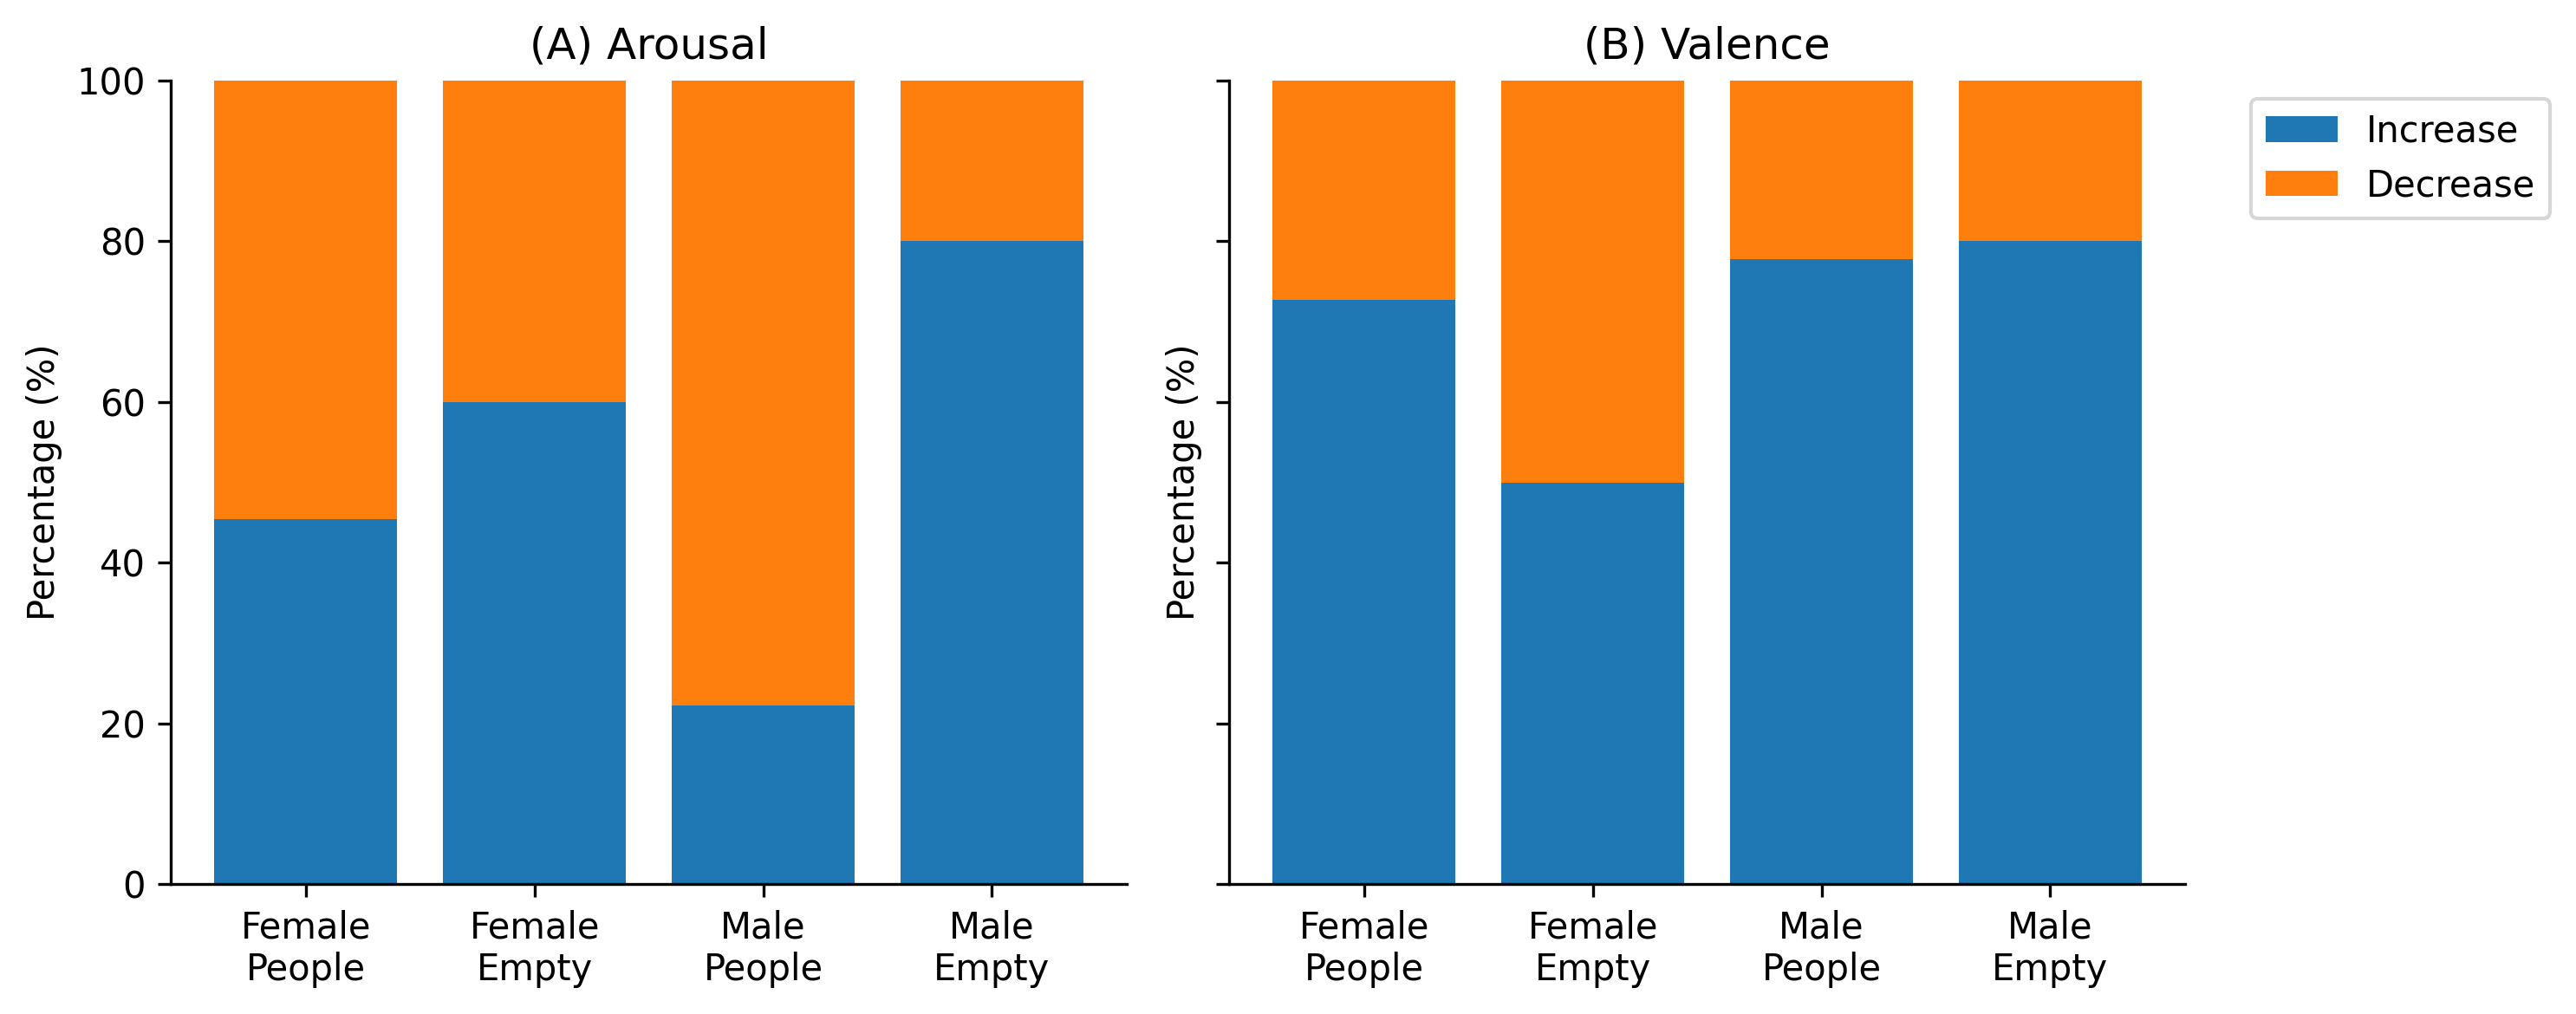

In [7]:
import pandas as pd
import matplotlib.pyplot as plt

# -----------------------------
# Load and prepare
# -----------------------------
df = pd.read_excel("TTest_Baseline.xlsx").rename(
    columns={"Unnamed: 8":"Gender"}
)

for c in ["Gender","Metric","Condition","Direction_vs_Baseline","Name"]:
    df[c] = df[c].astype(str).str.strip()

# Normalize gender labels
gender_map = {
    "F":"Female","Female":"Female","female":"Female",
    "M":"Male","Male":"Male","male":"Male"
}
df["Gender"] = df["Gender"].replace(gender_map)

# -----------------------------
# Split People vs Empty by row index
# -----------------------------
df_people = df.iloc[:40].copy()   # first 40 rows
df_empty  = df.iloc[40:].copy()   # 41+

df_people["Condition"] = "People"
df_empty["Condition"]  = "Empty"

df = pd.concat([df_people, df_empty], ignore_index=True)

# Keep metrics
metrics = ["Arousal_BL","Valence_BL"]
df = df[df["Metric"].isin(metrics)]

# -----------------------------
# Percentage calculation
# -----------------------------
summary = (
    pd.crosstab(
        index=[df["Metric"], df["Gender"], df["Condition"]],
        columns=df["Direction_vs_Baseline"]
    )
    .apply(lambda x: 100*x/x.sum(), axis=1)
    .reset_index()
)

# -----------------------------
# Plot
# -----------------------------
fig, axes = plt.subplots(1, 2, figsize=(10, 4), dpi=300, sharey=True)

def stacked_plot(ax, metric, title):
    sub = summary[summary["Metric"] == metric]

    labels = []
    inc = []
    dec = []

    for gender in ["Female","Male"]:
        for cond in ["People","Empty"]:
            row = sub[(sub["Gender"]==gender) & (sub["Condition"]==cond)]
            labels.append(f"{gender}\n{cond}")
            inc.append(row["Increase"].values[0])
            dec.append(row["Decrease"].values[0])

    x = range(len(labels))
    ax.bar(x, inc, label="Increase")
    ax.bar(x, dec, bottom=inc, label="Decrease")

    ax.set_xticks(x)
    ax.set_xticklabels(labels)
    ax.set_title(title)
    ax.set_ylabel("Percentage (%)")
    ax.set_ylim(0,100)
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)

stacked_plot(axes[0], "Arousal_BL", "(A) Arousal")
stacked_plot(axes[1], "Valence_BL", "(B) Valence")

axes[1].legend(bbox_to_anchor=(1.05,1), loc="upper left")
plt.tight_layout()
plt.show()
